<h4 style="font-size: 30px;"><strong>Packages</strong></h4>

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LogNorm, Normalize
import rioxarray
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin, Affine
from shapely.geometry import Point
import os
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D

<h4 style="font-size: 30px;"><strong>Paths</strong></h4>

In [5]:
radar_events = '../../DATA/rainfall/radar/'
landslide_events = '../../DATA/landslides/'
output_figures = '../../FIGURES/spatial_analysis/radar/'

<h4 style="font-size: 30px;"><strong>Functions</strong></h4>

In [7]:
def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade


def make_event_maps(dem, data, variables, nombres_variables, titulos, geojson_path, output_path, nombre_png, cmap='YlOrRd'):
    """
    Crea un conjunto de subplots con mapas de distintas variables de la lluvia y un DEM.

    Args:
        dem (xarray.DataArray): Modelo de elevación digital.
        data (dict): Diccionario con las variables climáticas.
        variables (list): Lista con los nombres de las variables climáticas.
        nombres_variables (list): Lista con los nombres de las variables climáticas.
        titulos (list): Lista con los títulos de los mapas.
        geojson_path (str): Ruta al archivo GeoJSON con el polígono de interés.
        output_path (str): Ruta de salida de las figuras.
        nombre_png (str): Nombre del archivo PNG de salida.
        cmap (str): Mapa de colores a utilizar.
    
    Returns:
        Figure: Figura con los subplots.
    """
    fig, axs = plt.subplots(2, 2, figsize=(18, 18))

    geojson = gpd.read_file(geojson_path)

    letters = ['A', 'B', 'C', 'D']

    for i, (ax, variable, nombre_variable, titulo) in enumerate(zip(axs.ravel(), variables, nombres_variables, titulos)):
        # Recortar datos con el polígono
        data_recortada = cut_with_polygon(data[variable], geojson)
        data_recortada = data_recortada.where(data_recortada >= 0)

        #norm = LogNorm(vmin=data_recortada.min(), vmax=data_recortada.max())
        #norm = Normalize(vmin=data_recortada.min(), vmax=data_recortada.max())
        #norm = Normalize(vmin=0, vmax=data_recortada.max())
        # Recortar el DEM con el polígono
        if dem.rio.crs != geojson.crs:
            poligono = geojson.to_crs(dem.rio.crs)
        dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

        # Crear el mapa de sombras primero
        sombra = hillshade(dem_recortado)
        extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
        ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

        # Crear el mapa con pcolormesh
        pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, shading='auto', alpha=0.6)

        # Formato de los ejes
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
        ax.tick_params(axis='both', which='major', labelsize=14)

        # Añadir el contorno del polígono
        geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)

        # Añadir la letra en la esquina superior izquierda
        ax.text(0.03, 0.98, letters[i], transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))


        ax.set_title(titulo, fontsize=16)

        # Añadir la escala gráfica utilizando matplotlib_scalebar
        distance_meters = 111320  # 1° = 111,32 km = 111320 m
        scalebar = ScaleBar(distance_meters, location='lower right', box_alpha=0.5, length_fraction=0.25,
                            scale_loc="top", font_properties={'size': 12}) #lower right
        ax.add_artist(scalebar)

        # Añadir el símbolo de norte
        img_path = f'{radar_events}norte.png'
        img = plt.imread(img_path)
        imgbox = OffsetImage(img, zoom=0.1, resample=True)
        ab = AnnotationBbox(imgbox, xy=(0.15, 0.92), xycoords='axes fraction', boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
        ax.add_artist(ab)
        
        # Añadir la barra de color individual dentro del subplot en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3]) 
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')
        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

    plt.tight_layout() 
    plt.savefig(f'{output_path}{nombre_png}', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()

def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    # Cargar el archivo CSV con las coordenadas
    coords_df = pd.read_csv(coord_file)
    
    # Suponiendo que las columnas del CSV son 'lon' y 'lat'
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    # Cargar el archivo netCDF
    data = xr.open_dataset(radar_file)
    
    # Crear la máscara inicialmente como True para todas las celdas
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])
    
    # Aplicar la máscara de exclusión para las coordenadas del CSV
    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    # Filtrar los datos aplicando la máscara
    data_filtrado = data.where(mask, drop=True)
    
    # Interpolación en las dimensiones 'lon' y 'lat'
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

<h4 style="font-size: 30px;"><strong>Filter areas with radar errors (radar location, mountains, etc.)</strong></h4>

In [4]:
data = xr.open_dataset(f'{radar_events}eventos_lluvia_1mm_1horas.nc')

# Extraer las variables y las coordenadas
lon = data['lon'].values
lat = data['lat'].values
acumulado_promedio = data['duracion_promedio'].values  # Usamos esta variable como ejemplo

# Definir la proyección WGS84 (EPSG:4326)
crs_wgs84 = 'EPSG:4326'


<h4 style="font-size: 20px;"><strong>Create .tif file with a variable</strong></h4>

In [ ]:
#============================================================================
'''
    Convertir a archivo .tif
'''
#============================================================================
# Extraer las variables y las coordenadas
lon = data['lon'].values  # Longitudes de las celdas del radar
lat = data['lat'].values  # Latitudes de las celdas del radar
acumulado_promedio = data['intensidad_promedio'].values  # Ejemplo de la variable acumulado_promedio

# Verificar si las longitudes están ordenadas de menor a mayor, si no, invertir
if lon[0] > lon[-1]:
    lon = lon[::-1]
    acumulado_promedio = acumulado_promedio[::-1, :] 

# Verificar si las latitudes están ordenadas de mayor a menor (de norte a sur), si no, invertir
if lat[0] < lat[-1]:
    lat = lat[::-1]
    acumulado_promedio = acumulado_promedio[:, ::-1]  

# Definir la transformación espacial
res_x = (lon.max() - lon.min()) / (len(lon) - 1) 
res_y = (lat.max() - lat.min()) / (len(lat) - 1)  

# Definir la transformación para que el origen esté en la esquina superior izquierda (noroeste)
transform = Affine.translation(lon.min() - res_x / 2, lat.max() + res_y / 2) * Affine.scale(res_x, -res_y)

# Definir las dimensiones del raster
width = len(lon)
height = len(lat)

# Crear el archivo .tif usando rasterio
with rasterio.open(
    f'{output_figures}/intensidad.tif',
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=rasterio.float64,
    crs='EPSG:4326',  # Sistema de coordenadas WGS84
    transform=transform,
) as dst:
    # Escribir los datos al archivo .tif
    dst.write(acumulado_promedio.T, 1)

<h4 style="font-size: 20px;"><strong>Create shapefile with the radar point grid</strong></h4>

In [ ]:
#============================================================================
'''
    Convertir las celdas del radar en puntos (malla) y exportar como shapefile.
'''
#============================================================================

# Crear una lista de puntos (coordenadas lon, lat) para la malla del radar
points = []
for i in range(len(lon)):
    for j in range(len(lat)):
        points.append(Point(lon[i], lat[j]))

# Crear un GeoDataFrame con los puntos y la proyección WGS84
gdf = gpd.GeoDataFrame(geometry=points, crs=crs_wgs84)

# Agregar columnas con los valores de las variables del radar
gdf['num_eventos'] = data['num_eventos'].values.flatten()
gdf['perc_num_eventos'] = data['perc_num_eventos'].values.flatten()
gdf['intensidad_promedio'] = data['intensidad_promedio'].values.flatten()
gdf['intensidad_maxima_promedio'] = data['intensidad_maxima_promedio'].values.flatten()
gdf['duracion_promedio'] = data['duracion_promedio'].values.flatten()
gdf['acumulado_promedio'] = data['acumulado_promedio'].values.flatten()

# Guardar el GeoDataFrame como un shapefile
gdf.to_file(f'{output_figures}/malla_puntos_radar_duracion.shp')

<h4 style="font-size: 20px;"><strong>1. The coordinates were found in QGis 3.26 with the .tif and the shapefile and saved in a .csv file</strong></h4>

<h4 style="font-size: 20px;"><strong>2. Filter coordinates</strong></h4>

<h4 style="font-size: 20px;"><strong>3. Interpolation of the areas without data</strong></h4>

In [4]:
# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'
file = f'{radar_events}eventos_lluvia_10mm_3horas.nc'

# Filtrar e interpolar los datos
interpolated_ds = filter_and_interpolate_data(file, coord_file)

<h4 style="font-size: 30px;"><strong>Graphics maps</strong></h4>

In [6]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
nombres_variables = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titulos = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']

dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

nombre_png = file.split('/')[-1].split('.')[0] + '_inter'


In [7]:
#cmap = 'jet'
make_event_maps(dem, interpolated_ds, variables, nombres_variables, titulos, 
                     geojson_path, output_figures, nombre_png)

<h4 style="font-size: 30px;"><strong>Day and night events</strong></h4>

In [ ]:
def list_filtered_files(directory):
    """
    Lista los archivos que terminan con '_dia.nc' o '_noche.nc'.
    """
    return [archivo for archivo in os.listdir(directory) if archivo.endswith(('_dia.nc', '_noche.nc'))]

In [ ]:
file_day_night = list_filtered_files(radar_events)

In [ ]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
nombres_variables = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titulos = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

In [ ]:
for file in file_day_night:
    # Filtrar e interpolar los datos
    interpolated_ds = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
    nombre_png = file.split('.')[0]
    
    make_event_maps(dem, interpolated_ds, variables, nombres_variables, titulos, 
                        geojson_path, output_figures, nombre_png)

<h4 style="font-size: 30px;"><strong>Rainfall and Landslides</strong></h4>

<h4 style="font-size: 20px;"><strong>Day and night events</strong></h4>

In [108]:
def make_event_maps_landslides(dem, data, variables, nombres_variables, titulos, geojson_path, output_path, nombre_png,landslides_dagrd):
    fig, axs = plt.subplots(2, 2, figsize=(18, 18))

    # Cargar polígono
    geojson = gpd.read_file(geojson_path)

    # Cargar el inventario de deslizamientos desde el shapefile
    #landslides_shp = gpd.read_file(landslides_shp_path)

    # Cargar el inventario de deslizamientos desde el archivo CSV
    # landslides_geohazard = pd.read_csv(landslides_geohazards)
    # landslides_geohazard_gdf = gpd.GeoDataFrame(
    #     landslides_geohazard, 
    #     geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
    #     crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    # )

    #landslides_dagrd = pd.read_csv(landslides_dagrd)
    landslides_dagrd_gdf = gpd.GeoDataFrame(
        landslides_dagrd, 
        geometry=gpd.points_from_xy(landslides_dagrd.longitud, landslides_dagrd.latitud),
        crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    )

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    #landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", op="within")

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    landslides_dagrd_gdf = gpd.sjoin(landslides_dagrd_gdf, geojson, how="inner", predicate="within")

    letters = ['A', 'B', 'C', 'D']

    # Diccionarios con los límites y ticks para cada variable
    limites_colorbar = {
        'num_eventos': {'vmin': 100, 'vmax': 700},
        'intensidad_promedio': {'vmin': 0, 'vmax': 14},
        'duracion_promedio': {'vmin': 1.0, 'vmax': 1.8},
        'acumulado_promedio': {'vmin': 0, 'vmax': 16},
    }

    ticks_colorbar = {
        'num_eventos': [100, 200, 300, 400, 500, 600, 700],
        'intensidad_promedio': [0, 2, 4, 6, 8, 10, 12, 14],
        'duracion_promedio': [1.0, 1.2, 1.4, 1.6, 1.8],
        'acumulado_promedio': [0, 2, 4, 6, 8, 10, 12, 14, 16],
    }

    for i, (ax, variable, nombre_variable, titulo) in enumerate(zip(axs.ravel(), variables, nombres_variables, titulos)):
        # Recortar datos con el polígono
        data_recortada = cut_with_polygon(data[variable], geojson)
        data_recortada = data_recortada.where(data_recortada >= 0)
        
        # Recortar el DEM con el polígono
        if dem.rio.crs != geojson.crs:
            poligono = geojson.to_crs(dem.rio.crs)
        dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

        # Crear el mapa de sombras primero
        sombra = hillshade(dem_recortado)
        extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
        ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

        # Obtener los límites y ticks para la variable actual
        limites = limites_colorbar.get(variable, {'vmin': None, 'vmax': None})
        ticks = ticks_colorbar.get(variable, None)
        
        # Crear el mapa con pcolormesh
        #cmap='YlOrRd'
        cmap='jet'
        pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T,
                            cmap=cmap, shading='auto', alpha=0.6,
                            vmin=limites['vmin'], vmax=limites['vmax'])

        # Añadir el contorno del polígono
        geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)

        # Añadir el inventario de deslizamientos desde el shapefile
        #landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7, label='Satellital inventory')

        # Añadir el inventario de deslizamientos desde el archivo CSV
        #landslides_geohazard_gdf.plot(ax=ax, marker='x', color='black', markersize=10, alpha=0.7, label='Geohazards inventory')

        # Añadir el inventario de deslizamientos desde el archivo CSV
        landslides_dagrd_gdf.plot(ax=ax, marker='x', color='black', markersize=10, alpha=0.7, label='Landslides')

        # Formato de los ejes
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
        ax.tick_params(axis='both', which='major', labelsize=14)

        ax.set_title(titulo, fontsize=16)

        # Añadir la escala gráfica utilizando matplotlib_scalebar
        distance_meters = 111320  # 1° = 111,32 km = 111320 m
        scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, length_fraction=0.25,
                            scale_loc="top", font_properties={'size': 12})
        ax.add_artist(scalebar)

        # Añadir la letra en la esquina superior izquierda
        ax.text(0.03, 0.98, letters[i], transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))

        # Añadir el símbolo de norte
        img_path = f'{radar_events}norte.png'
        img = plt.imread(img_path)
        imgbox = OffsetImage(img, zoom=0.1, resample=True)
        ab = AnnotationBbox(imgbox, xy=(0.15, 0.92), xycoords='axes fraction', boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
        ax.add_artist(ab)
        
        # Añadir la barra de color individual en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')

        # Configurar los ticks personalizados si existen
        if ticks is not None:
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([str(tick) for tick in ticks])

        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

        # Añadir leyenda
        ax.legend(loc='center left', bbox_to_anchor=(0.70, 0.5), fontsize=12)

    plt.tight_layout()  # Ajustar la disposición de los subplots
    plt.savefig(f'{output_path}{nombre_png}_landslides.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()


In [5]:
landslides_path = f'{landslide_events}/satellite_inventory/inventario_mm.shp'
landslides_geohazard = f'{landslide_events}inventory_GEOHAZARDS_20240824.csv'
landslides_dagrd = f'{landslide_events}inventory_SIATA.csv'

landslides_geohazard = pd.read_csv(landslides_geohazard)
ladnslide_dagr = pd.read_csv(landslides_dagrd)

In [101]:

# Asegurarse de que 'fecha_hora_evento' es de tipo datetime
ladnslide_dagr['fecha_hora_evento'] = pd.to_datetime(ladnslide_dagr['fecha_hora_evento'])

# Filtrar los eventos nocturnos (de 18:00 a 06:00)
eventos_noche = ladnslide_dagr[(ladnslide_dagr['fecha_hora_evento'].dt.hour >= 19) | 
                               (ladnslide_dagr['fecha_hora_evento'].dt.hour < 7)]

# Filtrar los eventos diurnos (de 06:00 a 18:00)
eventos_dia = ladnslide_dagr[(ladnslide_dagr['fecha_hora_evento'].dt.hour >= 7) & 
                             (ladnslide_dagr['fecha_hora_evento'].dt.hour < 19)]

In [112]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
nombres_variables = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titulos = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

In [113]:
# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_dia.nc'
interpolated_ds_dia = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
nombre_png = file.split('.')[0]
make_event_maps_landslides(dem, interpolated_ds_dia, variables, nombres_variables, titulos, geojson_path, output_figures, 
                           nombre_png,eventos_dia)

In [ ]:
file = 'eventos_lluvia_5mm_1horas_noche.nc'
interpolated_ds_noche = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
nombre_png = file.split('.')[0]

make_event_maps_landslides(dem, interpolated_ds_noche, variables, nombres_variables, titulos, geojson_path, output_figures, 
                           nombre_png,eventos_noche)

<h4 style="font-size: 30px;"><strong>Heavy, moderate and low rainfall events with landslides (Geohazards + Remote Sensors)</strong></h4>

In [25]:
def make_event_maps_landslides2(dem, data, variables, nombres_variables, 
                               titulos, geojson_path, output_path, nombre_png,
                               landslides_shp_path, landslides_geohazards):
    
    fig, axs = plt.subplots(2, 2, figsize=(18, 18))

    # Cargar polígono del amva
    geojson = gpd.read_file(geojson_path)

    # Cargar el inventario de sensores remotos
    landslides_shp = gpd.read_file(landslides_shp_path)

    # # Cargar el inventario Geohazards
    landslides_geohazard = pd.read_csv(landslides_geohazards)
    landslides_geohazard_gdf = gpd.GeoDataFrame(
         landslides_geohazard, 
         geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
         crs="EPSG:4326" 
     )

    # Cargar el inventario del DAGRD
    #landslides_dagrd = pd.read_csv(landslides_dagrd)
    # landslides_dagrd_gdf = gpd.GeoDataFrame(
    #     landslides_dagrd, 
    #     geometry=gpd.points_from_xy(landslides_dagrd.longitud, landslides_dagrd.latitud),
    #     crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    # )

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", predicate="within")

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    #landslides_dagrd_gdf = gpd.sjoin(landslides_dagrd_gdf, geojson, how="inner", predicate="within")

    letters = ['A', 'B', 'C', 'D']

    # Diccionarios con los límites y ticks para cada variable
    # limites_colorbar = {
    #     'num_eventos': {'vmin': 100, 'vmax': 700},
    #     'intensidad_promedio': {'vmin': 0, 'vmax': 14},
    #     'duracion_promedio': {'vmin': 1.0, 'vmax': 1.8},
    #     'acumulado_promedio': {'vmin': 0, 'vmax': 16},
    # }

    # ticks_colorbar = {
    #     'num_eventos': [100, 200, 300, 400, 500, 600, 700],
    #     'intensidad_promedio': [0, 2, 4, 6, 8, 10, 12, 14],
    #     'duracion_promedio': [1.0, 1.2, 1.4, 1.6, 1.8],
    #     'acumulado_promedio': [0, 2, 4, 6, 8, 10, 12, 14, 16],
    # }

    for i, (ax, variable, nombre_variable, titulo) in enumerate(zip(axs.ravel(), variables, 
                                                                    nombres_variables, titulos)):
        # Recortar datos con el polígono del amva
        data_recortada = cut_with_polygon(data[variable], geojson)
        data_recortada = data_recortada.where(data_recortada >= 0)

        #Guardar las coordenadas latitud y longitud antes de normalizar
        #lon = data_recortada['lon']
        #lat = data_recortada['lat']

        #Normalizar solo los valores de la variable, no las coordenadas
        #scaler = MinMaxScaler()
        #data_recortada = scaler.fit_transform(data_recortada.values.reshape(-1, 1)).reshape(data_recortada.shape)



        # Recortar el DEM con el polígono del amva
        if dem.rio.crs != geojson.crs:
            poligono = geojson.to_crs(dem.rio.crs)
        dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

        # Crear el mapa de sombras primero
        sombra = hillshade(dem_recortado)
        extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
        ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

        # Obtener los límites y ticks para la variable actual
        # limites = limites_colorbar.get(variable, {'vmin': None, 'vmax': None})
        # ticks = ticks_colorbar.get(variable, None)
               
        # Crear el mapa con pcolormesh usando las coordenadas originales
        #cmap='YlOrRd'
        cmap='jet'
        #pcm = ax.pcolormesh(lon, lat, data_recortada.T, cmap=cmap, shading='auto', alpha=0.6)
        
        pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T,
                             cmap=cmap, shading='auto', alpha=0.6)

        # Añadir el contorno del polígono
        geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)

        # Añadir el inventario de deslizamientos de los sensores remotos
        landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7,
                            label='Landslides')

        # Añadir el inventario de deslizamientos de Geohazards
        landslides_geohazard_gdf.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7)

        # Añadir el inventario de deslizamientos desde el archivo CSV
        #landslides_dagrd_gdf.plot(ax=ax, marker='x', color='black', markersize=10, alpha=0.7, label='Landslides')

        # Formato de los ejes
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
        ax.tick_params(axis='both', which='major', labelsize=14)

        ax.set_title(titulo, fontsize=16)

        # Añadir la escala gráfica
        distance_meters = 111320  # 1° = 111,32 km = 111320 m
        scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, 
                            length_fraction=0.25,
                            scale_loc="top", 
                            font_properties={'size': 12})
        ax.add_artist(scalebar)

        # Añadir la letra en la esquina superior izquierda
        ax.text(0.03, 0.98, letters[i], transform=ax.transAxes, fontsize=20, fontweight='bold', 
                va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))

        # Añadir el símbolo de norte
        img_path = f'{radar_events}norte.png'
        img = plt.imread(img_path)
        imgbox = OffsetImage(img, zoom=0.1, resample=True)
        ab = AnnotationBbox(imgbox, xy=(0.15, 0.92), xycoords='axes fraction',
                            boxcoords='axes fraction', 
                            pad=0, bboxprops=dict(edgecolor='white'))
        ax.add_artist(ab)
        
        # Añadir la barra de color individual en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')

        # Configurar los ticks personalizados si existen
        # if ticks is not None:
        #     cbar.set_ticks(ticks)
        #     cbar.set_ticklabels([str(tick) for tick in ticks])

        # Añadir la barra de color individual dentro del subplot en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3]) 
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')
        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

        # Añadir leyenda
        ax.legend(loc='center left', bbox_to_anchor=(0.70, 0.5), fontsize=12)

    plt.tight_layout() 
    plt.savefig(f'{output_path}{nombre_png}_land.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()

In [6]:
landslides_remote_sensors = f'{landslide_events}/satellite_inventory/inventario_mm.shp'
landslides_geohazard = f'{landslide_events}inventory_GEOHAZARDS_20240824.csv'

In [ ]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_intensidad_0_15.nc'

interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

make_event_maps_landslides2(dem, interpolated_ds_0_15, variables, variables_name, titles, geojson_path, output_figures, 
                           name_png,landslides_remote_sensors, landslides_geohazard)

#make_event_maps_landslides2(dem, interpolated_ds_0_15, variables, variables_name, titles, 
#                           geojson_path, output_figures, name_png)


In [ ]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_intensidad_15_30.nc'

interpolated_ds_15_30 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

make_event_maps_landslides2(dem, interpolated_ds_15_30, variables, variables_name, titles, geojson_path, output_figures, 
                           name_png,landslides_remote_sensors, landslides_geohazard)

#make_event_maps_landslides2(dem, interpolated_ds_15_30, variables, variables_name, titles, 
#                            geojson_path, output_figures, name_png)


In [ ]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_intensidad_30_plus.nc'

interpolated_ds_30 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

make_event_maps_landslides2(dem, interpolated_ds_30, variables, variables_name, titles, geojson_path, output_figures, 
                           name_png,landslides_remote_sensors, landslides_geohazard)

#make_event_maps_landslides2(dem, interpolated_ds_30, variables, variables_name, titles, geojson_path, output_figures, 
#                           name_png)

# **PAPER**

<h4 style="font-size: 20px;"><strong>Heavy (>15 mm) and low (<15 mm) rainfall events with landslides (Geohazards + Remote Sensors).</strong></h4>

In [59]:
def make_individual_event_map(dem, data, variable, nombre_variable, titulo,
                               geojson_path, output_path, nombre_png, 
                               landslides_shp_path, landslides_geohazards, 
                               radar_csv_path,
                               letter,
                               cmap='jet'):
    
    fig, ax = plt.subplots(figsize=(8, 9)) # Tamaño del mapa: 
    
    # ────────── polígonos y deslizamientos ──────────
    # Cargar polígono del amva
    geojson = gpd.read_file(geojson_path)
    
    # Cargar el inventario de sensores remotos
    landslides_shp = gpd.read_file(landslides_shp_path)

    # Cargar el inventario Geohazards
    landslides_geohazard = pd.read_csv(landslides_geohazards)
    landslides_geohazard = landslides_geohazard.drop_duplicates(subset=['Norte', 'Este'])  # Eliminar duplicados
    landslides_geohazard_gdf = gpd.GeoDataFrame(
        landslides_geohazard, 
        geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
        crs="EPSG:4326" 
    )

        # Radar
    radar_df  = pd.read_csv(radar_csv_path)   # columnas: latitud, longitud
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )

    # ────────── reproyecciones ──────────
    # Reproyectar si los CRS no coinciden
    for gdf in (landslides_shp, landslides_geohazard_gdf, radar_gdf):
        if gdf.crs != geojson.crs:
            gdf.to_crs(geojson.crs, inplace=True)


    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", predicate="within")
    landslides_shp = gpd.sjoin(landslides_shp, geojson, how="inner", predicate="within")

    # ────────── datos ráster y DEM ──────────

    # Recortar datos con el polígono del amva
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)
    
    # Recortar el DEM con el polígono del amva
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Crear el mapa de sombras primero
    sombra = hillshade(dem_recortado)
    extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

  
    # Definir vmin y vmax para mejorar la visualización de la barra de color
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35
    
    # Crear el mapa con pcolormesh
    pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, shading='auto', alpha=0.6)
    #pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, 
    #                    shading='auto', alpha=0.6, vmin=vmin, vmax=vmax)
    # Añadir el contorno del polígono
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    # Añadir el inventario de deslizamientos de los sensores remotos
    landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.3, label='Landslides')

    # Añadir el inventario de deslizamientos de Geohazards
    landslides_geohazard_gdf.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.3)

    radar_gdf.plot(ax=ax, marker='*', color='limegreen',
                    markersize=220,
                   edgecolor='black', linewidth=0.6, label='Weather Radar',
                   zorder = 5)


    # Formato de los ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    #ax.set_title(titulo, fontsize=16)

    # ────────── ejes, escala, norte, colorbar ──────────
    distance_meters = 111320  # 1° = 111,32 km = 111320 m
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, 
                        length_fraction=0.25,
                        scale_loc="top", 
                        font_properties={'size': 12})
    ax.add_artist(scalebar)

    # Añadir el símbolo de norte
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', 
                        pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)
    
    # Añadir la barra de color individual con intervalos específicos para ciertas variables
    cax = ax.inset_axes([0.75, 0.04, 0.05, 0.3]) # explica los parametros: [x, y, width, height]
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Definir ticks específicos para ciertas variables
    # if variable == 'intensidad_promedio':
    #     cbar.set_ticks([5, 10, 15, 20, 25, 30])
    # elif variable == 'duracion_promedio':
    #     cbar.set_ticks([1, 1.25, 1.5, 1.75, 2.0])
    # elif variable == 'acumulado_promedio':
    #     cbar.set_ticks([5, 10, 15, 20, 25, 30, 35])

    # ────────── leyenda ──────────
    handles, labels = ax.get_legend_handles_labels()

    # ─── reemplazos con tamaños distintos en la leyenda ─
    handle_landslides = Line2D([], [], marker='o', linestyle='None',
                            markerfacecolor='black', markeredgecolor='black',
                            markersize=8,
                            label='Landslides')       # un poco más grande
    handle_radar = Line2D([], [], marker='*', linestyle='None',
                        markerfacecolor='limegreen', markeredgecolor='black',
                        markersize=14,                  # un poco más pequeño
                        label='Weather Radar')

    # elimina los originales y añade los nuevos
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Landslides', 'Weather Radar'):
            new_handles.append(h)
            new_labels.append(lab)

    new_handles.extend([handle_landslides, handle_radar])
    new_labels.extend(['Landslides', 'Weather Radar'])

    ax.text(0.03, 0.98, letter, transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='top', 
            ha='left', bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels,
            loc='center left', bbox_to_anchor=(0.62, 0.45),
            fontsize=12, frameon=False)
    
    plt.tight_layout() 
    plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    #plt.show()
    plt.close()

In [60]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of rainfall events\n (< 15 mm/h)', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
#geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
geojson_path = '../../DATA/shape_files/aburra.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_intensidad_0_15.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

landslides_remote_sensors = f'{landslide_events}/satellite_inventory/inventario_mm.shp'
landslides_remote_sensors_2 = f'{landslide_events}/Landslides_VdeA_13jun2025/Landslides_VdeA_13jun2025.shp'
landslides_geohazard = f'{landslide_events}inventory_GEOHAZARDS_20240824.csv'
radar = f'../../DATA/coords_radar.csv'
letter = 'a'

# make_individual_event_map(dem, interpolated_ds_0_15, 'num_eventos', 'Number of rainfall events\n (< 15 mm/h)',
#                            'Number of rainfall events', geojson_path, 
#                             output_figures, name_png,
#                             landslides_remote_sensors_2,
#                             landslides_geohazard,
#                             radar,
#                             letter)
# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
                              output_figures, name_png, landslides_remote_sensors_2, landslides_geohazard,
                              radar,
                              letter)

In [61]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of rainfall events\n (> 15 mm/h)', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
#geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
geojson_path = '../../DATA/shape_files/aburra.geojson'


# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_intensidad_15_plus.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

landslides_remote_sensors = f'{landslide_events}/satellite_inventory/inventario_mm.shp'
landslides_remote_sensors_2 = f'{landslide_events}/Landslides_VdeA_13jun2025/Landslides_VdeA_13jun2025.shp'
landslides_geohazard = f'{landslide_events}inventory_GEOHAZARDS_20240824.csv'
radar = f'../../DATA/coords_radar.csv'
letter = 'b'


# make_individual_event_map(dem, interpolated_ds_0_15, 'num_eventos', 'Number of rainfall events\n (> 15 mm/h)',
#                            'Number of rainfall events', geojson_path, 
#                             output_figures, name_png,
#                             landslides_remote_sensors_2,
#                             landslides_geohazard,
#                             radar,
#                             letter)


# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path,
                              output_figures, name_png, landslides_remote_sensors_2, landslides_geohazard,
                              radar,
                              letter)

<h4 style="font-size: 20px;"><strong>Heavy (>15 mm) and low (<15 mm) rainfall events with landslides (DAGRD) for Day and night.</strong></h4>

In [6]:
def make_event_maps_landslides(dem, data, variables, nombres_variables, titulos, geojson_path, output_path, nombre_png,landslides_dagrd):
    fig, axs = plt.subplots(2, 2, figsize=(18, 18))

    # Cargar polígono
    geojson = gpd.read_file(geojson_path)

    # Cargar el inventario de deslizamientos desde el shapefile
    #landslides_shp = gpd.read_file(landslides_shp_path)

    # Cargar el inventario de deslizamientos desde el archivo CSV
    # landslides_geohazard = pd.read_csv(landslides_geohazards)
    # landslides_geohazard_gdf = gpd.GeoDataFrame(
    #     landslides_geohazard, 
    #     geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
    #     crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    # )

    #landslides_dagrd = pd.read_csv(landslides_dagrd)
    landslides_dagrd_gdf = gpd.GeoDataFrame(
        landslides_dagrd, 
        geometry=gpd.points_from_xy(landslides_dagrd.longitud, landslides_dagrd.latitud),
        crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    )

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    #landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", op="within")

    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    landslides_dagrd_gdf = gpd.sjoin(landslides_dagrd_gdf, geojson, how="inner", predicate="within")

    letters = ['A', 'B', 'C', 'D']

    # Diccionarios con los límites y ticks para cada variable
    # limites_colorbar = {
    #     'num_eventos': {'vmin': 100, 'vmax': 700},
    #     'intensidad_promedio': {'vmin': 0, 'vmax': 14},
    #     'duracion_promedio': {'vmin': 1.0, 'vmax': 1.8},
    #     'acumulado_promedio': {'vmin': 0, 'vmax': 16},
    # }

    # ticks_colorbar = {
    #     'num_eventos': [100, 200, 300, 400, 500, 600, 700],
    #     'intensidad_promedio': [0, 2, 4, 6, 8, 10, 12, 14],
    #     'duracion_promedio': [1.0, 1.2, 1.4, 1.6, 1.8],
    #     'acumulado_promedio': [0, 2, 4, 6, 8, 10, 12, 14, 16],
    # }

    for i, (ax, variable, nombre_variable, titulo) in enumerate(zip(axs.ravel(), variables, nombres_variables, titulos)):
        # Recortar datos con el polígono
        data_recortada = cut_with_polygon(data[variable], geojson)
        data_recortada = data_recortada.where(data_recortada >= 0)
        
        # Recortar el DEM con el polígono
        if dem.rio.crs != geojson.crs:
            poligono = geojson.to_crs(dem.rio.crs)
        dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

        # Crear el mapa de sombras primero
        sombra = hillshade(dem_recortado)
        extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
        ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

        # Obtener los límites y ticks para la variable actual
        # limites = limites_colorbar.get(variable, {'vmin': None, 'vmax': None})
        # ticks = ticks_colorbar.get(variable, None)
        
        # Crear el mapa con pcolormesh
        #cmap='YlOrRd'
        cmap='jet'
        pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T,
                            cmap=cmap, shading='auto', alpha=0.6)

        # Añadir el contorno del polígono
        geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)

        # Añadir el inventario de deslizamientos desde el shapefile
        #landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7, label='Satellital inventory')

        # Añadir el inventario de deslizamientos desde el archivo CSV
        #landslides_geohazard_gdf.plot(ax=ax, marker='x', color='black', markersize=10, alpha=0.7, label='Geohazards inventory')

        # Añadir el inventario de deslizamientos desde el archivo CSV
        landslides_dagrd_gdf.plot(ax=ax, marker='x', color='black', markersize=10, alpha=0.7, label='Landslides')

         # Dividir los deslizamientos dentro y fuera del área urbana
        deslizamientos_urbanos = landslides_dagrd_gdf[landsides_dagrd_gdf.within(urbano.unary_union)]
        deslizamientos_no_urbanos = landslides_dagrd_gdf[~landslides_dagrd_gdf.within(urbano.unary_union)]
        
        # Añadir los deslizamientos como círculos si están dentro del área urbana
        deslizamientos_urbanos.plot(ax=ax, marker='o', color='gray', edgecolor='k', markersize=10, 
                                    alpha=0.6, label='Landslides (Urban Area)')
        
        # Añadir los deslizamientos como triángulos si están fuera del área urbana
        deslizamientos_no_urbanos.plot(ax=ax, marker='^', color='gray', edgecolor='k', markersize=10, alpha=0.6, label='Landslides (Non-Urban Area)')
        


        # Formato de los ejes
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
        ax.tick_params(axis='both', which='major', labelsize=14)

        #ax.set_title(titulo, fontsize=16)

        # Añadir la escala gráfica utilizando matplotlib_scalebar
        distance_meters = 111320  # 1° = 111,32 km = 111320 m
        scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, length_fraction=0.25,
                            scale_loc="top", font_properties={'size': 12})
        ax.add_artist(scalebar)

        # Añadir la letra en la esquina superior izquierda
        ax.text(0.03, 0.98, letters[i], transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))

        # Añadir el símbolo de norte
        img_path = f'{radar_events}norte.png'
        img = plt.imread(img_path)
        imgbox = OffsetImage(img, zoom=0.1, resample=True)
        ab = AnnotationBbox(imgbox, xy=(0.15, 0.92), xycoords='axes fraction', boxcoords='axes fraction', pad=0, bboxprops=dict(edgecolor='white'))
        ax.add_artist(ab)
        
        # Añadir la barra de color individual en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')

        # Configurar los ticks personalizados si existen
        # if ticks is not None:
        #     cbar.set_ticks(ticks)
        #     cbar.set_ticklabels([str(tick) for tick in ticks])
         # Añadir la barra de color individual dentro del subplot en la parte inferior derecha
        cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3]) 
        cbar = fig.colorbar(pcm, cax=cax, extend='neither')
        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

        cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
        cbar.ax.tick_params(labelsize=10)

        # Añadir leyenda
        ax.legend(loc='center left', bbox_to_anchor=(0.70, 0.5), fontsize=12)

    plt.tight_layout()  # Ajustar la disposición de los subplots
    plt.savefig(f'{output_path}{nombre_png}_landslides.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    #plt.show()
    plt.close()

In [1]:
def make_individual_event_map(dem, data, variable, nombre_variable, titulo, geojson_path, 
                              output_path, nombre_png, landslides_dagrd, cmap='jet'):
    fig, ax = plt.subplots(figsize=(8, 9)) # Tamaño del mapa: 
    
    # Cargar polígono del amva
    geojson = gpd.read_file(geojson_path)
    #urbano = gpd.read_file(poligono_urbano)
    # Cargar el inventario de sensores remotos
    #landslides_shp = gpd.read_file(landslides_shp_path)

    # Cargar el inventario Geohazards
    # landslides_geohazard = pd.read_csv(landslides_geohazards)
    # landslides_geohazard_gdf = gpd.GeoDataFrame(
    #     landslides_geohazard, 
    #     geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
    #     crs="EPSG:4326" 
    # )

    #landslides_dagrd = pd.read_csv(landslides_dagrd)
    landslides_dagrd_gdf = gpd.GeoDataFrame(
        landslides_dagrd, 
        geometry=gpd.points_from_xy(landslides_dagrd.longitud, landslides_dagrd.latitud),
        crs="EPSG:4326"  # Asegúrate de que el CRS sea correcto
    )

    # Reproyectar si los CRS no coinciden
    #if landslides_shp.crs != geojson.crs:
    #    landslides_shp = landslides_shp.to_crs(geojson.crs)
    #if landslides_geohazard_gdf.crs != geojson.crs:
    #    landslides_geohazard_gdf = landslides_geohazard_gdf.to_crs(geojson.crs)
    if landslides_dagrd_gdf.crs != geojson.crs:
        landslides_dagrd_gdf = landslides_dagrd_gdf.to_crs(geojson.crs)
    
    #if urbano.crs != geojson.crs:
    #    urbano = urbano.to_crs(geojson.crs)
    
    # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    #landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", predicate="within")
    #landslides_shp = gpd.sjoin(landslides_shp, geojson, how="inner", predicate="within")
    landslides_dagrd_gdf = gpd.sjoin(landslides_dagrd_gdf, geojson, how="inner", predicate="within")

    # Recortar datos con el polígono del amva
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)
    
    # Recortar el DEM con el polígono del amva
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Crear el mapa de sombras primero
    sombra = hillshade(dem_recortado)
    extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    #0-15
    #Definir vmin y vmax para mejorar la visualización de la barra de color
    # vmin, vmax = None, None
    # if variable == 'num_eventos':
    #     vmin, vmax = 0, 600
    # elif variable == 'intensidad_promedio':
    #     vmin, vmax = 5, 9
    # elif variable == 'duracion_promedio':
    #     vmin, vmax = 1, 1.5
    # elif variable == 'acumulado_promedio':
    #     vmin, vmax = 6, 11

    # > 15
    # Definir vmin y vmax para mejorar la visualización de la barra de color
    # vmin, vmax = None, None
    # if variable == 'num_eventos':
    #     vmin, vmax = 0, 140
    # elif variable == 'intensidad_promedio':
    #     vmin, vmax = 0, 30
    # elif variable == 'duracion_promedio':
    #     vmin, vmax = 1, 3.0
    # elif variable == 'acumulado_promedio':
    #     vmin, vmax = 0, 40
    

    #Exceden el percentil 95%
    vmin, vmax = None, None
    # if variable == 'num_eventos':
    #     vmin, vmax = 0, 60
    # elif variable == 'intensidad_promedio':
    #     vmin, vmax = 0, 40
    # elif variable == 'duracion_promedio':
    #     vmin, vmax = 1, 2.0
    # elif variable == 'acumulado_promedio':
    #     vmin, vmax = 0, 50
    
    if variable == 'Int_max':
        vmin, vmax = 5, 9
    elif variable == 'Int_media':
        vmin, vmax = 5, 11
    elif variable == 'Duracion':
        vmin, vmax = 1, 1.5
    elif variable == 'Acumulado':
        vmin, vmax = 6, 11


    # Crear el mapa con pcolormesh
    #pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, shading='auto', alpha=0.6)
    pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, 
                        shading='auto', alpha=0.6, vmin=vmin, vmax=vmax)
    # Añadir el contorno del polígono
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)
    
    #urbano.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.5)
    # Añadir el inventario de deslizamientos de los sensores remotos
    #landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7, label='Landslides')

    # Añadir el inventario de deslizamientos de Geohazards
    #landslides_geohazard_gdf.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7)
    # Dividir los deslizamientos dentro y fuera del área urbana
    #deslizamientos_urbanos = landslides_dagrd_gdf[landslides_dagrd_gdf.within(urbano.unary_union)]
    #deslizamientos_no_urbanos = landslides_dagrd_gdf[~landslides_dagrd_gdf.within(urbano.unary_union)]
    
    # Añadir los deslizamientos como círculos si están dentro del área urbana
    #deslizamientos_urbanos.plot(ax=ax, marker='o', color='gray', edgecolor='k', markersize=10, 
    #                            alpha=0.6, label='Landslides (Urban Area)')
    
    # Añadir los deslizamientos como triángulos si están fuera del área urbana
    #deslizamientos_no_urbanos.plot(ax=ax, marker='^', color='gray', edgecolor='k', markersize=10, 
    #                               alpha=0.6, label='Landslides (Non-Urban Area)')
    # Añadir el inventario de deslizamientos de DAGRD
    #landslides_dagrd_gdf.plot(ax=ax, marker='o', color='gray', edgecolor = 'k', markersize=10, alpha=0.6, label='Landslides')

    #urbano.plot(ax=ax, edgecolor="m", facecolor="none", hatch='o', linewidth=1, label='Urban area')
    #urbano.boundary.plot(ax=ax, edgecolor="purple", linewidth=1, label='Urban area')
    # Formato de los ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    #ax.set_title(titulo, fontsize=16)

    # Añadir la escala gráfica
    distance_meters = 111320  # 1° = 111,32 km = 111320 m
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, 
                        length_fraction=0.25,
                        scale_loc="top", 
                        font_properties={'size': 12})
    ax.add_artist(scalebar)

    # Añadir el símbolo de norte
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', 
                        pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)
    
    # Añadir la barra de color individual con intervalos específicos para ciertas variables
    cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    #0-15
    #Definir ticks específicos para ciertas variables
    # if variable == 'num_eventos':
    #     cbar.set_ticks([0, 100, 200, 300, 400, 500, 600])
    # elif variable == 'intensidad_promedio':
    #     cbar.set_ticks([5, 6, 7, 8, 9])
    # elif variable == 'duracion_promedio':
    #     cbar.set_ticks([1, 1.1, 1.2, 1.3, 1.4, 1.5])
    # elif variable == 'acumulado_promedio':
    #     cbar.set_ticks([6, 7, 8, 9, 10, 11])

    # > 15
    # if variable == 'num_eventos':
    #     cbar.set_ticks([0, 20, 40, 60, 80, 100, 120, 140])
    # elif variable == 'intensidad_promedio':
    #     cbar.set_ticks([0, 5, 10, 15, 20, 25, 30])
    # elif variable == 'duracion_promedio':
    #     cbar.set_ticks([1, 1.5, 2.0, 2.5, 3.0])
    # elif variable == 'acumulado_promedio':
    #     cbar.set_ticks([0, 5, 10, 15, 20, 25, 30, 35, 40])


    # if variable == 'num_eventos':
    #     cbar.set_ticks([0, 5, 10, 20, 30, 40, 50, 60])
    # elif variable == 'intensidad_promedio':
    #     cbar.set_ticks([0, 10, 15, 20, 25, 30, 35, 40])
    # elif variable == 'duracion_promedio':
    #     cbar.set_ticks([1, 1.25, 1.5, 1.75, 2.0])
    # elif variable == 'acumulado_promedio':
    #     cbar.set_ticks([0, 10, 15, 20, 25, 30, 35, 40, 45, 50])

    if variable == 'Int_max':
        cbar.set_ticks([5, 6, 7, 8, 9])
    elif variable == 'Int_media':
        cbar.set_ticks([5, 6, 7, 8, 9, 10, 11])
    elif variable == 'Duracion':
        cbar.set_ticks([1, 1.1, 1.2, 1.3, 1.4, 1.5])
    elif variable == 'Acumulado':
        cbar.set_ticks([6, 7, 8, 9, 10, 11])

    


    # Añadir leyenda
    ax.legend(loc='center left', bbox_to_anchor=(0.7, 0.55), fontsize=12)

    plt.tight_layout() 
    #plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.show()
    plt.close()

CON POLIGONO URBANO

In [16]:
def make_individual_event_map(
        dem, data, variable, nombre_variable, titulo,
        geojson_path, output_path, nombre_png,
        landslides_dagrd, cmap='jet'):

    fig, ax = plt.subplots(figsize=(8, 9))

    # ──────── 1. CAPAS VECTOR ────────
    geojson = gpd.read_file(geojson_path)

    # deslizamientos DAGRD  → GeoDataFrame
    gdf_ls = gpd.GeoDataFrame(
        landslides_dagrd,
        geometry=gpd.points_from_xy(
            landslides_dagrd.longitud,
            landslides_dagrd.latitud),
        crs='EPSG:4326'
    )
    if gdf_ls.crs != geojson.crs:
        gdf_ls = gdf_ls.to_crs(geojson.crs)

    # solo los puntos dentro del polígono
    gdf_ls = gpd.sjoin(gdf_ls, geojson, predicate='within', how='inner')

    # ──────── 2. RECORTES RÁSTER ────────
    if dem.rio.crs != geojson.crs:
        poly_dem = geojson.to_crs(dem.rio.crs)
    else:
        poly_dem = geojson
    dem_clip = dem.rio.clip(poly_dem.geometry, poly_dem.crs)

    data_clip = cut_with_polygon(data[variable], geojson).where(lambda x: x >= 0)

    # ──────── 3. LÍMITES ÚNICOS PARA TODO ────────
    xmin, ymin, xmax, ymax = geojson.total_bounds   # una vez, mismo “viewport”

    # ──────── 4. HILLSHADE ────────
    sombra = hillshade(dem_clip)
    ax.imshow(
        np.flipud(sombra),
        cmap='gray',
        origin='lower',
        extent=[xmin, xmax, ymin, ymax],
        alpha=0.5,
        zorder=0
    )

    # ──────── 5. CAMPOS PSEUDO-COLOR ────────
    vmins = dict(num_eventos=(0, 600),
                 intensidad_promedio=(5, 9),
                 duracion_promedio=(1, 1.5),
                 acumulado_promedio=(6, 11))
    vmin, vmax = vmins.get(variable, (None, None))

    pcm = ax.pcolormesh(
        data_clip['lon'], data_clip['lat'], data_clip.T,
        cmap=cmap, shading='auto', alpha=0.6,
        vmin=vmin, vmax=vmax, zorder=2
    )

    # ──────── 6. CONTORNO Y PUNTOS ────────
    geojson.boundary.plot(ax=ax, edgecolor='black', linewidth=0.6, zorder=3)
    gdf_ls.plot(ax=ax, marker='o', color='gray',
                edgecolor='k', markersize=10, alpha=0.6,
                label='Landslides', zorder=4)

    # ──────── 7. FORMATO EJE ────────
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')                  # evita estiramientos
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}° N"))
    ax.tick_params(labelsize=14)
    ax.set_title(titulo, fontsize=16)

    # ──────── 8. ESCALA, NORTE, COLORBAR ────────
    ax.add_artist(ScaleBar(111_320, length_fraction=0.25,
                           location='lower right', scale_loc='top',
                           box_alpha=0.5, font_properties={'size': 12}))

    ab = AnnotationBbox(OffsetImage(plt.imread(f'{radar_events}norte.png'),
                                    zoom=0.1, resample=True),
                        xy=(0.08, 0.92), xycoords='axes fraction',
                        frameon=False)
    ax.add_artist(ab)

    cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # ticks fijos
    ticks = dict(num_eventos=range(0, 601, 100),
                 intensidad_promedio=range(5, 10),
                 duracion_promedio=np.linspace(1, 1.5, 6),
                 acumulado_promedio=range(6, 12))
    if variable in ticks:
        cbar.set_ticks(ticks[variable])

    ax.legend(loc='center left', bbox_to_anchor=(0.52, 0.55), fontsize=12)

    plt.tight_layout()
    plt.show()
    plt.close()


<h4 style="font-size: 15px;"><strong>DAGRD inventory</strong></h4>

In [12]:
landslides_dagrd = f'{landslide_events}inventory_SIATA.csv'
#landslides_dagrd = f'{landslide_events}bd_eventos_dagrd_materializados.csv'
#landslides_dagrd = f'{landslide_events}dagrd_12062025.csv'
#landslides_dagrd = f'{landslide_events}dagrd_12062025.csv'
landslides_dagrd = pd.read_csv(landslides_dagrd)

# Asegurarse de que 'fecha_hora_evento' es de tipo datetime
#landslides_dagrd['fecha_hora_evento'] = pd.to_datetime(landslides_dagrd['fecha_hora_evento'])
landslides_dagrd['fecha_hora_evento'] = pd.to_datetime(landslides_dagrd['fecha_hora_evento'])
#landslides_dagrd['fecha_ocur'] = pd.to_datetime(landslides_dagrd['fecha_ocur'])
# Filtrar los eventos nocturnos (de 19:00 a 07:00)
eventos_noche = landslides_dagrd[(landslides_dagrd['fecha_hora_evento'].dt.hour >= 18) | 
                              (landslides_dagrd['fecha_hora_evento'].dt.hour < 6)]
# eventos_noche = landslides_dagrd[(landslides_dagrd['fecha_ocurrencia'].dt.hour >= 18) | 
#                                (landslides_dagrd['fecha_ocurrencia'].dt.hour < 6)]

# Filtrar los eventos diurnos (de 06:00 a 18:00)
eventos_dia = landslides_dagrd[(landslides_dagrd['fecha_hora_evento'].dt.hour >= 6) & 
                            (landslides_dagrd['fecha_hora_evento'].dt.hour < 18)]
# eventos_dia = landslides_dagrd[(landslides_dagrd['fecha_ocurrencia'].dt.hour >= 6) & 
#                              (landslides_dagrd['fecha_ocurrencia'].dt.hour < 18)]

<h4 style="font-size: 15px;"><strong>Day.</strong></h4>

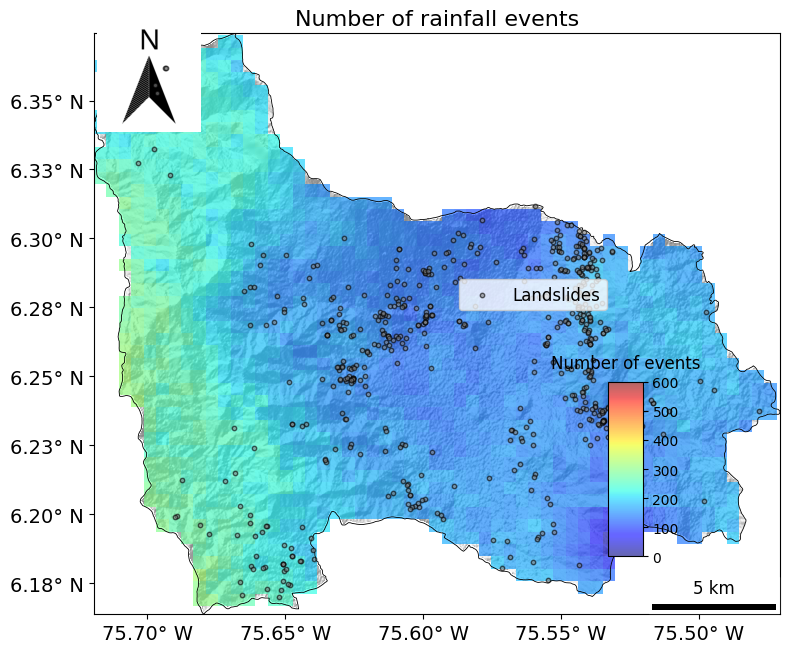

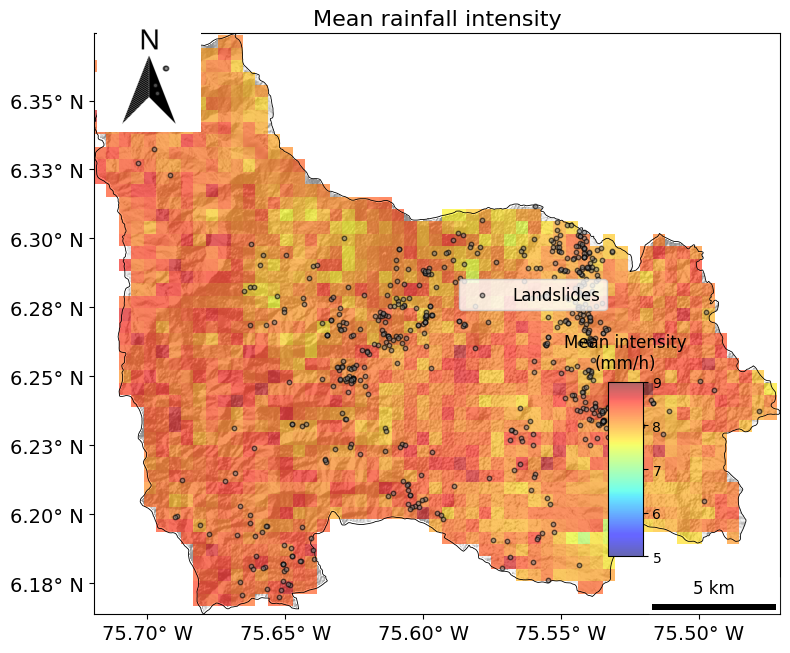

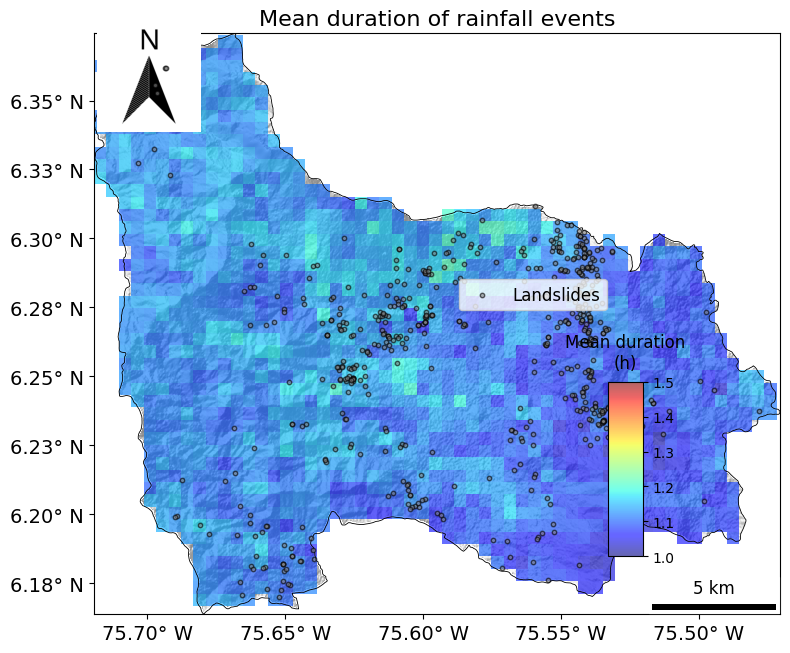

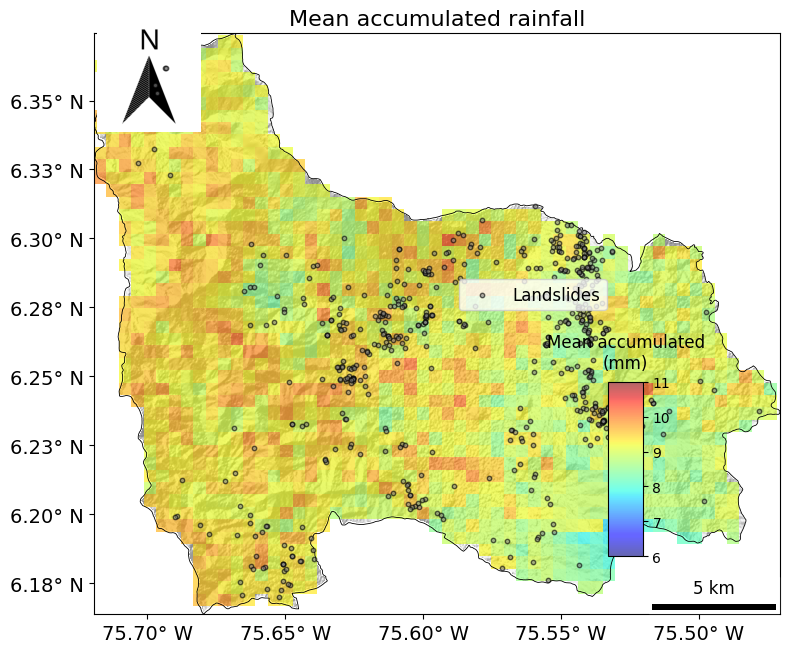

In [17]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
#variables = ['Int_max', 'Int_media', 'Duracion', 'Acumulado', 'P95']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
#variables_name = ['Max intensity\n(mm/h)', 'Mean intensity\n(mm/h)', 'Duration\n(h)', 'Accumulated\n(mm)', 'P95']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
#titles = ['Max intensity', 'Mean intensity', 'Duration', 'Accumulated', 'P95']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
#geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
geojson_path = '../../DATA/shape_files/med.geojson'
#poligono_urbano = '../../DATA/med.geojson'
# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_dia_intensidad_0_15.nc'
# DATOS QUE EXCEDEN EL PERCENTIL 95%
#file = 'eventos_lluvia_5mm_1horas_dia_5exc.nc'
#file = 'eventos_lluvia_5mm_1horas_dia_p95.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, 
                              variable, 
                              nombre_variable,
                              titulo, geojson_path, 
                              output_figures, 
                              name_png,
                              eventos_dia)

# Generar los mapas individuales para cada variable
# for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
#     make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
#                               output_figures, name_png, eventos_dia, poligono_urbano)

In [12]:
#variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables = ['Int_max', 'Int_media', 'Duracion', 'Acumulado', 'P95']
#variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
variables_name = ['Max intensity\n(mm/h)', 'Mean intensity\n(mm/h)', 'Duration\n(h)', 'Accumulated\n(mm)', 'P95']
#titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
titles = ['Max intensity', 'Mean intensity', 'Duration', 'Accumulated', 'P95']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_dia_intensidad_15_plus.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
                              output_figures, name_png, eventos_dia)

# Generar los mapas individuales para cada variable
# for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
#     make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
#                               output_figures, name_png, eventos_dia, poligono_urbano)

<h4 style="font-size: 15px;"><strong>Night.</strong></h4>

In [18]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
#geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
geojson_path = '../../DATA/shape_files/med.geojson'
# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_noche_intensidad_0_15.nc'
# DATOS QUE EXCEDEN EL PERCENTIL 95%
#file = 'eventos_lluvia_5mm_1horas_noche_5exc.nc'
#file = 'eventos_lluvia_5mm_1horas_noche_p95.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]


for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
                              output_figures, name_png, eventos_noche)

# Generar los mapas individuales para cada variable
# for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
#     make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
#                               output_figures, name_png, eventos_noche, poligono_urbano)

FileNotFoundError: [Errno 2] No such file or directory: '/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_noche_intensidad_0_15.nc'

In [13]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas_noche_intensidad_15_plus.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
                              output_figures, name_png, eventos_noche)

# Generar los mapas individuales para cada variable
# for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
#     make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
#                               output_figures, name_png, eventos_noche, poligono_urbano)

In [8]:
landslides_dagrd = f'{landslide_events}inventory_SIATA.csv'
landslides_dagrd = pd.read_csv(landslides_dagrd)

# Asegurarse de que 'fecha_hora_evento' es de tipo datetime
landslides_dagrd['fecha_hora_evento'] = pd.to_datetime(landslides_dagrd['fecha_hora_evento'])

# Filtrar los eventos nocturnos (de 19:00 a 07:00)
eventos_noche = landslides_dagrd[(landslides_dagrd['fecha_hora_evento'].dt.hour >= 19) | 
                               (landslides_dagrd['fecha_hora_evento'].dt.hour < 7)]

# Filtrar los eventos diurnos (de 06:00 a 18:00)
eventos_dia = landslides_dagrd[(landslides_dagrd['fecha_hora_evento'].dt.hour >= 7) & 
                             (landslides_dagrd['fecha_hora_evento'].dt.hour < 19)]

In [13]:
variables = ['num_eventos', 'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Number of events', 'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Number of rainfall events', 'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
#dia
#file = 'eventos_lluvia_5mm_1horas_dia_intensidad_0_15.nc'
#file = 'eventos_lluvia_5mm_1horas_dia_intensidad_15_30.nc'
#file = 'eventos_lluvia_5mm_1horas_dia_intensidad_30_plus.nc'

#landslide
#landslides_dagrd = eventos_dia

# #noche
#file = 'eventos_lluvia_5mm_1horas_noche_intensidad_0_15.nc'
#file = 'eventos_lluvia_5mm_1horas_noche_intensidad_15_30.nc'
file = 'eventos_lluvia_5mm_1horas_noche_intensidad_30_plus.nc'

#landslide
landslides_dagrd = eventos_noche


interpolated_ds_30 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

make_event_maps_landslides(dem, interpolated_ds_30, variables, variables_name, titles, 
                            geojson_path, output_figures, name_png,landslides_dagrd)

### **EVALUAR LA LLUVIA PARA LA INSTLACIÓN DE PLUVIOMETROS**

In [8]:
def make_individual_event_map(dem, data, variable, nombre_variable, titulo, geojson_path, output_path, nombre_png, landslides_shp_path, landslides_geohazards, cmap='jet'):
    fig, ax = plt.subplots(figsize=(8, 9)) # Tamaño del mapa: 
    
    # Cargar polígono del amva
    geojson = gpd.read_file(geojson_path)
    
    # # Cargar el inventario de sensores remotos
    # landslides_shp = gpd.read_file(landslides_shp_path)

    # # Cargar el inventario Geohazards
    # landslides_geohazard = pd.read_csv(landslides_geohazards)
    # landslides_geohazard_gdf = gpd.GeoDataFrame(
    #     landslides_geohazard, 
    #     geometry=gpd.points_from_xy(landslides_geohazard.Este, landslides_geohazard.Norte),
    #     crs="EPSG:4326" 
    # )

    #graficas ubiccion pluviometros

    ruta_metadata = '/home/oisanchezp/Rainfall/data/metadata/pluvios_meta.csv'
    metadata_estaciones = pd.read_csv(ruta_metadata)

    metadata_activas = metadata_estaciones[metadata_estaciones['estado'] == 'A']
    metadata_activas = metadata_activas.sort_values(by='Codigo', ascending=True)
    metadata_activas = metadata_activas[:-1]

    pluvios_coords = metadata_activas[['Longitude', 'Latitude']].values[:]
    x_pluvios, y_pluvios = pluvios_coords[:, 0], pluvios_coords[:, 1]






    # Reproyectar si los CRS no coinciden
    # if landslides_shp.crs != geojson.crs:
    #     landslides_shp = landslides_shp.to_crs(geojson.crs)
    # if landslides_geohazard_gdf.crs != geojson.crs:
    #     landslides_geohazard_gdf = landslides_geohazard_gdf.to_crs(geojson.crs)

    # # Filtrar los puntos del inventario de deslizamientos que están dentro del polígono
    # landslides_geohazard_gdf = gpd.sjoin(landslides_geohazard_gdf, geojson, how="inner", predicate="within")
    # landslides_shp = gpd.sjoin(landslides_shp, geojson, how="inner", predicate="within")

    # Recortar datos con el polígono del amva
    data_recortada = cut_with_polygon(data[variable], geojson)
    data_recortada = data_recortada.where(data_recortada >= 0)
    
    # Recortar el DEM con el polígono del amva
    if dem.rio.crs != geojson.crs:
        poligono = geojson.to_crs(dem.rio.crs)
    dem_recortado = dem.rio.clip(poligono.geometry, poligono.crs)

    # Crear el mapa de sombras primero
    sombra = hillshade(dem_recortado)
    extent = [data['lon'].min(), data['lon'].max(), data['lat'].min(), data['lat'].max()]
    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower', extent=extent, alpha=0.5)

    # Definir vmin y vmax para mejorar la visualización de la barra de color
    vmin, vmax = None, None
    if variable == 'intensidad_promedio':
        vmin, vmax = 5, 30
    elif variable == 'duracion_promedio':
        vmin, vmax = 1, 2.0
    elif variable == 'acumulado_promedio':
        vmin, vmax = 5, 35
    
    # Crear el mapa con pcolormesh
    pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, shading='auto', alpha=0.6)
    #pcm = ax.pcolormesh(data_recortada['lon'], data_recortada['lat'], data_recortada.T, cmap=cmap, 
    #                    shading='auto', alpha=0.6, vmin=vmin, vmax=vmax)
    # Añadir el contorno del polígono
    geojson.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)

        # Añadir puntos de pluviómetros
    ax.scatter(x_pluvios, y_pluvios, c='black', 
               s=40, edgecolor='black', linewidth=0.5,
               alpha=0.7, label='Pluviómetros')
    
    
    # Añadir el inventario de deslizamientos de los sensores remotos
    #landslides_shp.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7, label='Landslides')

    # Añadir el inventario de deslizamientos de Geohazards
    #landslides_geohazard_gdf.plot(ax=ax, marker='o', color='black', markersize=10, alpha=0.7)

    # Formato de los ejes
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}° N"))
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    #ax.set_title(titulo, fontsize=16)

    # Añadir la escala gráfica
    distance_meters = 111320  # 1° = 111,32 km = 111320 m
    scalebar = ScaleBar(distance_meters, location="lower right", box_alpha=0.5, 
                        length_fraction=0.25,
                        scale_loc="top", 
                        font_properties={'size': 12})
    ax.add_artist(scalebar)

    # Añadir el símbolo de norte
    img_path = f'{radar_events}norte.png'
    img = plt.imread(img_path)
    imgbox = OffsetImage(img, zoom=0.1, resample=True)
    ab = AnnotationBbox(imgbox, xy=(0.1, 0.92), xycoords='axes fraction',
                        boxcoords='axes fraction', 
                        pad=0, bboxprops=dict(edgecolor='white'))
    ax.add_artist(ab)
    
    # Añadir la barra de color individual con intervalos específicos para ciertas variables
    cax = ax.inset_axes([0.75, 0.1, 0.05, 0.3])
    cbar = fig.colorbar(pcm, cax=cax, extend='neither')
    cbar.ax.set_title(nombre_variable, fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Definir ticks específicos para ciertas variables
    # if variable == 'intensidad_promedio':
    #     cbar.set_ticks([5, 10, 15, 20, 25, 30])
    # elif variable == 'duracion_promedio':
    #     cbar.set_ticks([1, 1.25, 1.5, 1.75, 2.0])
    # elif variable == 'acumulado_promedio':
    #     cbar.set_ticks([5, 10, 15, 20, 25, 30, 35])

    # Añadir leyenda
    ax.legend(loc='center left', bbox_to_anchor=(0.70, 0.5), fontsize=12)

    plt.tight_layout() 
    #plt.savefig(f'{output_path}{nombre_png}_{variable}.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    plt.savefig('/home/oisanchezp/Rainfall/results/lluvia_radar.png', bbox_inches='tight', pad_inches=0.1, dpi=100)
    #plt.show()
    plt.close()

In [11]:
variables = ['num_eventos'] #'intensidad_promedio', 'duracion_promedio', 'acumulado_promedio']
variables_name = ['Número de eventos de lluvia'] #'Mean intensity\n(mm/h)', 'Mean duration\n(h)', 'Mean accumulated\n(mm)']
titles = ['Número de eventos de lluvia'] #'Mean rainfall intensity', 'Mean duration of rainfall events', 'Mean accumulated rainfall']
dem_path = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'
dem = rioxarray.open_rasterio(dem_path, mask_and_scale=True)
geojson_path = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'

# Cargar el archivo CSV con las coordenadas
coord_file = f'{radar_events}coordenadas_que_no.csv'

# Filtrar e interpolar los datos
file = 'eventos_lluvia_5mm_1horas.nc'
interpolated_ds_0_15 = filter_and_interpolate_data(f'{radar_events}{file}', coord_file)
name_png = file.split('.')[0]

landslides_remote_sensors = f'{landslide_events}/satellite_inventory/inventario_mm.shp'
landslides_geohazard = f'{landslide_events}inventory_GEOHAZARDS_20240824.csv'

# Generar los mapas individuales para cada variable
for variable, nombre_variable, titulo in zip(variables, variables_name, titles):
    make_individual_event_map(dem, interpolated_ds_0_15, variable, nombre_variable, titulo, geojson_path, 
                              output_figures, name_png, landslides_remote_sensors, landslides_geohazard)